In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# Install the Chronos engine directly from Amazon's source
!pip install -q git+https://github.com/amazon-science/chronos-forecasting.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 106.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.7 MB/s eta 0:00:00


In [5]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chronos import ChronosPipeline
from statsmodels.tsa.seasonal import STL

In [6]:
# 1. Load the Brain (Using GPU)
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small", 
    device_map="cuda", 
    torch_dtype=torch.bfloat16
)

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

In [7]:
# 2. Load the Dataset
url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df = pd.read_csv(url)
# We take the last part of the 'OT' (Oil Temperature) column
data_np = df['OT'].values[-608:] 
ground_truth = torch.tensor(data_np[-96:]).to(torch.float32)
context_np = data_np[:-96]

In [8]:
# --- 🚀 THE MASTERY MOVE: ALGORITHM 1 (Structure-Sensitive) ---
def get_dsi_pro_perturbation(context_array, eta=0.01):
    # STL splits data into Trend, Seasonality, and Resid
    # We use a period of 24 because ETTh1 is hourly data
    res = STL(context_array, period=24).fit()
    
    # Identify Trend shifts (where the model usually gets confused)
    trend_diff = np.abs(np.gradient(res.trend))
    
    # Create noise that hits the 'unstable' parts harder
    noise = np.random.normal(0, 1, len(context_array))
    # Combine trend sensitivity + residual noise
    f = (trend_diff + np.abs(res.resid)) * noise
    
    # Normalize so we don't destroy the data (Fidelity check)
    f_norm = f * (np.linalg.norm(context_array) / (np.linalg.norm(f) + 1e-6))
    
    return torch.tensor(context_array + (eta * f_norm)).to(torch.float32)

In [9]:
# --- 📊 THE SCALING BATTLE ---
scaling_steps = [1, 8, 64] # Compare Small vs Medium vs Big compute
results = {}

for N in scaling_steps:
    print(f"Scaling Inference to N={N}...")
    all_preds = []
    for _ in range(N):
        shaken = get_dsi_pro_perturbation(context_np)
        with torch.no_grad():
            all_preds.append(pipeline.predict(shaken, 96)[0])
    
    # Majority Vote (Median)
    dsi_final = torch.median(torch.stack(all_preds).view(-1, 96), dim=0).values
    results[N] = dsi_final

Scaling Inference to N=1...


Scaling Inference to N=8...


Scaling Inference to N=64...


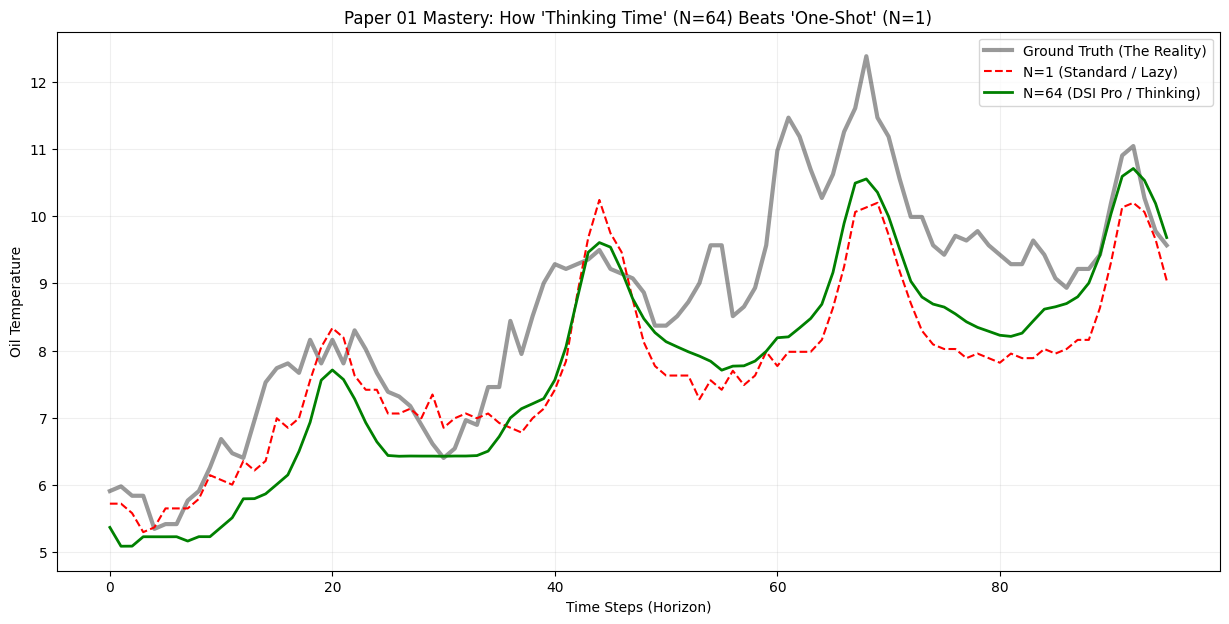

In [10]:
# --- 📈 THE SHOWDOWN PLOT ---
plt.figure(figsize=(15, 7))
plt.plot(ground_truth.cpu(), label="Ground Truth (The Reality)", color="black", linewidth=3, alpha=0.4)
plt.plot(results[1].cpu(), label="N=1 (Standard / Lazy)", color="red", linestyle="--")
plt.plot(results[64].cpu(), label="N=64 (DSI Pro / Thinking)", color="green", linewidth=2)

plt.title("Paper 01 Mastery: How 'Thinking Time' (N=64) Beats 'One-Shot' (N=1)")
plt.xlabel("Time Steps (Horizon)")
plt.ylabel("Oil Temperature")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()